In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.stats import norm
from scipy.optimize import minimize
from copy import deepcopy
from sklearn.linear_model import LinearRegression
import torch
import torch.nn as nn
#import scipy linear regression
import statsmodels.api as sm
from scipy.stats import t as t_dist
import numpy as np
from scipy.stats import ttest_ind

In [2]:
# parameters setting
K = 100
T = 1000
#Z = norm.ppf(0.975)
N = 10
Z = t_dist.ppf(0.975,N)
anchor_mean = 1
std_niose = 3
anchor_set = [1,2,3,4,5]
std_noise_set = [1,2,3,4,5]

### Calcate boxplot

In [4]:
cost = np.zeros((3,T))
accuracy = np.zeros((3,1000))
recall = np.zeros((3,1000))
FPR = np.zeros((3,1000))
precision = np.zeros((3,1000))
N = N+K
for idx,anchor_mean in enumerate([1]):
    for t in tqdm(range(T)):
        true_tao = np.random.normal(anchor_mean, 3, K)
        constant = np.random.normal(anchor_mean, 3)
        optimal_cost = np.sum(true_tao[np.argwhere(true_tao>0)])

        # generate data
        feature = np.ones((N, K+1)) 
        feature[:, 1:] = np.random.binomial(1, 0.5, (N,K))

        # generate label
        label = constant + np.dot(feature[:,1:], true_tao) + np.random.normal(0, std_niose, N)


        #-------------DiM Method----------------
        X = np.zeros((K,N))
        Y = np.zeros((K,N))
        for k in range(K):
            X[k,:] = feature[:,k+1]
            Y[k,:] = label
        

        #DM
        tao_hat = np.zeros(K)
        variance = np.zeros(K)
        #variance1 = np.zeros(K)
        p_value_list = np.zeros(K)
        for k in range(K):
            group_1 = Y[k,X[k,:]==1]
            group_0 = Y[k,X[k,:]==0]
            t_stat, p_value = ttest_ind(group_1, group_0, equal_var = False)  
            diff_mean = group_1.mean() - group_0.mean()
            tao_hat[k] = diff_mean
            p_value_list[k] = p_value
            variance[k] = N*(group_1.var(ddof=1) / len(group_1) + group_0.var(ddof=1) / len(group_0))
        

        tao_0 = np.mean(tao_hat)
        numerator = np.mean(variance)
        denumerator = np.mean((tao_hat - tao_0)**2) - numerator/N

        bayesian_tao = np.zeros(K)
        bayesian_beta = np.zeros(K)

        decision3 = []
  
        for k in range(K):
            if denumerator <= 0:
                theta = 1
                posteri_mean = tao_hat[k]*theta + (1 - theta)*tao_0
                posteri_var = 1/(N/variance[k])
                dist = norm(loc=posteri_mean, scale=np.sqrt(posteri_var))
                prob = dist.sf(0)  # survival function: P(X > x)
                if prob > 1 - 0.025:
                    decision3.append(k)
            else:
                bayesian_beta[k] = max(variance[k]/denumerator,0)
                theta = N/(N+bayesian_beta[k])
                posteri_mean = tao_hat[k]*theta + (1 - theta)*tao_0
                posteri_var = 1/(1/denumerator+ N/variance[k])
                dist = norm(loc=posteri_mean, scale=np.sqrt(posteri_var))

                prob = dist.sf(0)  # survival function: P(X > x)
                if prob > 1 - 0.025:
                    decision3.append(k)


        
        if anchor_mean != 0:
            beta = numerator/denumerator + Z*np.sqrt(N*numerator)/tao_0
            beta = max(0,beta)
            theta = N/(N+beta)
            #shunken_saa
            tao_shunken_hat = np.zeros(K)
            p_value_list_shrunken = np.zeros(K)
            Y_shunken = deepcopy(Y)
            Y_shunken = theta*Y_shunken 
            for k in range(K):
                group_1 = Y_shunken[k,X[k,:]==1] + (1-theta)*tao_0
                group_0 = Y_shunken[k,X[k,:]==0]
                t_stat, p_value = ttest_ind(group_1, group_0, equal_var = False)  
                diff_mean1 = group_1.mean() - group_0.mean()
                tao_shunken_hat[k] = diff_mean1
                p_value_list_shrunken[k] = p_value
            
        
            decision1 = np.intersect1d(np.argwhere(p_value_list<0.05), np.argwhere(tao_hat>0))
            decision2 = np.intersect1d(np.argwhere(p_value_list_shrunken<0.05), np.argwhere(tao_shunken_hat>0))
      
            cost[0,t] = np.sum(true_tao[decision1])/optimal_cost
            cost[1,t] = np.sum(true_tao[decision2])/optimal_cost
            cost[2,t] = np.sum(true_tao[decision3])/optimal_cost


        

        for k in range(K):
            if (true_tao[k] < 0 and k not in decision1) or (true_tao[k] > 0 and k in decision1):
                accuracy[0,t] += 1
            if (true_tao[k] < 0 and k not in decision2) or (true_tao[k] > 0 and k in decision2):
                accuracy[1,t] += 1
            if (true_tao[k] < 0 and k not in decision3) or (true_tao[k] > 0 and k in decision3):
                accuracy[2,t] += 1
            if true_tao[k] > 0 and k in decision1:
                recall[0,t] += 1
            if true_tao[k] > 0 and k in decision2:
                recall[1,t] += 1
            if true_tao[k] > 0 and k in decision3:
                recall[2,t] += 1
            if true_tao[k] < 0 and k in decision1:
                FPR[0,t] += 1
            if true_tao[k] <0 and k in decision2:
                FPR[1,t] += 1
            if true_tao[k] < 0 and k in decision3:
                FPR[2,t] += 1
        if recall[0,t] + FPR[0,t] == 0:
            precision[0,t] = 1
        else:
            precision[0,t] = recall[0,t]/(recall[0,t] + FPR[0,t] )
        if recall[1,t] + FPR[1,t] == 0:
            precision[1,t] = 1
        else:
            precision[1,t] = recall[1,t]/(recall[1,t] + FPR[1,t] )
        if recall[2,t] + FPR[2,t] == 0:
            precision[2,t] = 1
        else:
            precision[2,t] = recall[2,t]/(recall[2,t] + FPR[2,t] )
        accuracy[:,t] = accuracy[:,t]/K
        recall[:,t] = recall[:,t]/(len(np.argwhere(true_tao>0)))
        FPR[:,t] = FPR[:,t]/(len(np.argwhere(true_tao<0)))

100%|██████████| 1000/1000 [02:38<00:00,  6.30it/s]


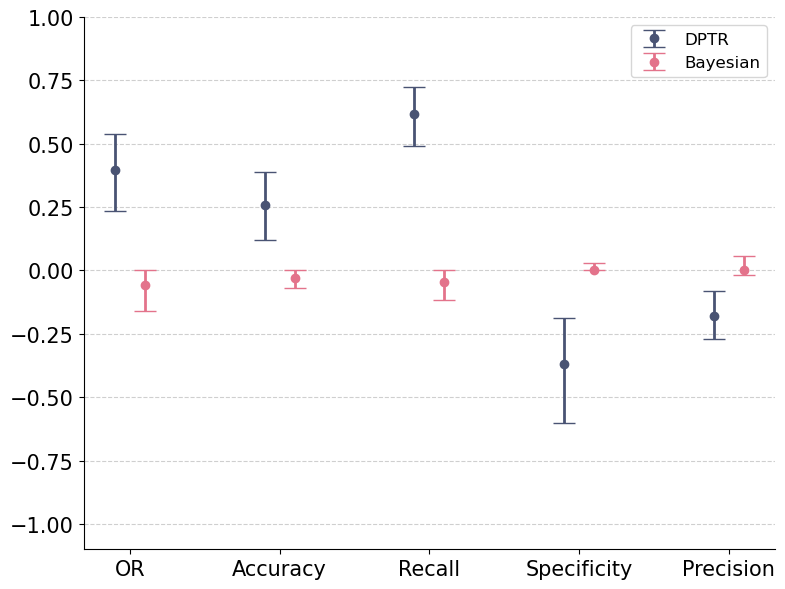

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st


def mean_ci(data_array):
    means = []
    lowers = []
    uppers = []
    for d in data_array:
        mean = np.mean(d)
        ci_low, ci_high = np.percentile(d, [2.5, 97.5])
        means.append(mean)
        lowers.append(mean - ci_low)
        uppers.append(ci_high - mean)
    return np.array(means), np.array(lowers), np.array(uppers)

# 原始数据差值
data = [
    cost[1,:] - cost[0,:],
    accuracy[1,:] - accuracy[0,:],
    recall[1,:] - recall[0,:],
    FPR[0,:] - FPR[1,:],
    precision[1,:] - precision[0,:]
]

data1 = [
    cost[2,:] - cost[0,:],
    accuracy[2,:] - accuracy[0,:],
    recall[2,:] - recall[0,:],
    FPR[0,:] - FPR[2,:],
    precision[2,:] - precision[0,:]
]

# 计算均值和置信区间
mean_dtr, err_low_dtr, err_up_dtr = mean_ci(data)
mean_bayes, err_low_bayes, err_up_bayes = mean_ci(data1)

# 横坐标
x = np.arange(5)
width = 0.2

# 绘图
fig, ax = plt.subplots(figsize=(8, 6))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# DTR误差条（左移一点）
ax.errorbar(x - width/2, mean_dtr, yerr=[err_low_dtr, err_up_dtr], fmt='o', 
            capsize=8, markersize=6, color='#495373', ecolor='#495373', label='DPTR', linewidth=2)

# Bayesian误差条（右移一点）
ax.errorbar(x + width/2, mean_bayes, yerr=[err_low_bayes, err_up_bayes], fmt='o', 
            capsize=8, markersize=6, color='#E3738B', ecolor='#E3738B', label='Bayesian', linewidth=2)

# 设置x轴
ax.set_xticks(x)
ax.set_xticklabels(['OR', 'Accuracy', 'Recall', 'Specificity', 'Precision'], fontsize=15)

# 图例与样式
ax.legend(fontsize=12, loc='upper right')
ax.set_ylim(-1.1, 1)
ax.tick_params(axis='y', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('scenario3_figures/Scenario3_basic_for_dim.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


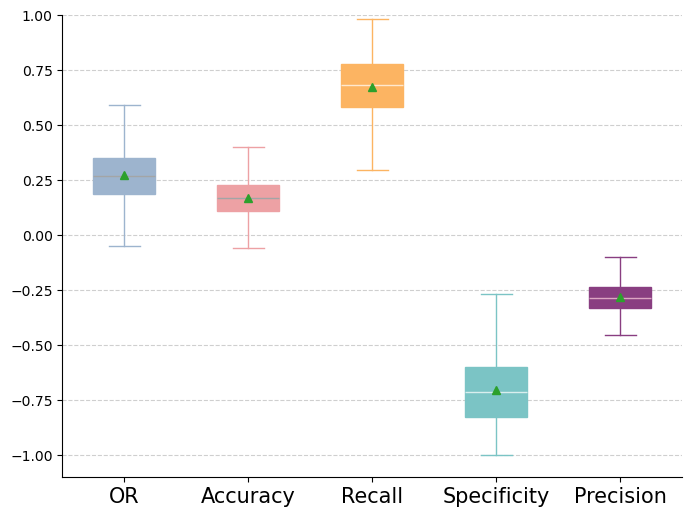

In [ ]:
fig, ax = plt.subplots(figsize = (8,6))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
data = [cost[0,1,:] - cost[0,0,:],accuracy[1,:] - accuracy[0,:],recall[1,:] - recall[0,:],FPR[0,:] - FPR[1,:],precision[1,:] - precision[0,:]]

bp = plt.boxplot(data,showfliers=False,showmeans=True,patch_artist=True)
# 定义每个箱子的颜色
colors = [ '#9DB4CE','#EDA1A4','#FCB462','#7BC4C5','#893E81']
colors1 = ['#A3A5A6' ,'#A3A5A6','#FFE8CE','#D9EEEE','#DCA5C3']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
    
for whisker, color in zip(bp['whiskers'], [colors[i // 2] for i in range(len(bp['whiskers']))]):
    whisker.set_color(color)

for cap, color in zip(bp['caps'], [colors[i // 2] for i in range(len(bp['caps']))]):
    cap.set_color(color)

for median, color in zip(bp['medians'], colors1):
    median.set_color(color)

for flier, color in zip(bp['fliers'], [colors[i // 2] for i in range(len(bp['fliers']))]):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

plt.ylim(-1.1,1)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
# 设置x轴标签
plt.xticks([1, 2,3,4,5], ['OR','Accuracy','Recall','Specificity','Precision'],fontsize=15)

# 设置y轴标签
#plt.ylabel('Values')
# 设置图标题
#plt.title('Boxplot of Different Groups')

# 显示图形
#plt.savefig('scenario3_figures/boxplot_basic_overlap.png',dpi = 300,bbox_inches = 'tight')
plt.show()

### Calculate OR value

#### 1, change with anchor mean

In [13]:
# parameters setting
K =100
T = 1000
N = 10
Z = t_dist.ppf(0.975,N)
std_niose = 3
anchor_set = [1,2,3,4,5]
N = K + N

cost = np.zeros((len(anchor_set),3,T))
for idx,anchor_mean in enumerate(anchor_set):
    for t in tqdm(range(T)):
        true_tao = np.random.normal(anchor_mean, 3, K )
        constant = np.random.normal(anchor_mean, 3)
        optimal_cost = np.sum(true_tao[np.argwhere(true_tao>0)])

        # generate data
        feature = np.ones((N, K+1)) 
        feature[:, 1:] = np.random.binomial(1, 0.5, (N,K))

        # generate label
        label = constant + np.dot(feature[:,1:], true_tao) + np.random.normal(0, std_niose, N)

        #-------------DiM Method----------------
        X = np.zeros((K,N))
        Y = np.zeros((K,N))
        for k in range(K):
            X[k,:] = feature[:,k+1]
            Y[k,:] = label
        

        #DM
        tao_hat = np.zeros(K)
        variance = np.zeros(K)
        #variance1 = np.zeros(K)
        p_value_list = np.zeros(K)
        for k in range(K):
            group_1 = Y[k,X[k,:]==1]
            group_0 = Y[k,X[k,:]==0]
            t_stat, p_value = ttest_ind(group_1, group_0, equal_var = False)  
            diff_mean = group_1.mean() - group_0.mean()
            tao_hat[k] = diff_mean
            p_value_list[k] = p_value
            variance[k] = N*(group_1.var(ddof=1) / len(group_1) + group_0.var(ddof=1) / len(group_0))
        #estimated cost
        decision1 = np.argwhere(tao_hat>(Z*np.sqrt(variance)))
        if optimal_cost == 0:
            if len(decision1) == 0:
                cost[idx,0,t] = 1
            else:
                cost[idx,0,t] = 0
        else:
            cost[idx,0,t] = np.sum(true_tao[decision1])/optimal_cost
        

        tao_0 = np.mean(tao_hat)
        numerator = np.mean(variance)
        denumerator = np.mean((tao_hat - tao_0)**2) - numerator/N

        bayesian_tao = np.zeros(K)
        bayesian_beta = np.zeros(K)

        decision3 = []
  
        for k in range(K):
            if denumerator <= 0:
                theta = 1
                posteri_mean = tao_hat[k]*theta + (1 - theta)*tao_0
                posteri_var = 1/(N/variance[k])
                dist = norm(loc=posteri_mean, scale=np.sqrt(posteri_var))
                prob = dist.sf(0)  # survival function: P(X > x)
                if prob > 1 - 0.025:
                    decision3.append(k)
            else:
                bayesian_beta[k] = max(variance[k]/denumerator,0)
                theta = N/(N+bayesian_beta[k])
                posteri_mean = tao_hat[k]*theta + (1 - theta)*tao_0
                posteri_var = 1/(1/denumerator+ N/variance[k])
                dist = norm(loc=posteri_mean, scale=np.sqrt(posteri_var))

                prob = dist.sf(0)  # survival function: P(X > x)
                if prob > 1 - 0.025:
                    decision3.append(k)

        if optimal_cost == 0:
            if len(decision3) == 0:
                cost[idx,2,t] = 1
            else:
                cost[idx,2,t] = 0
        else:
            cost[idx,2,t] = np.sum(true_tao[decision3])/optimal_cost

        
        
        if tao_0 == 0:
            cost[idx,1,t] = cost[idx,0,t]
            continue
        beta = numerator/denumerator + Z*np.sqrt(N*numerator)/tao_0
        beta = max(0,beta)
        theta = N/(N+beta)
        #shunken_saa
        tao_shunken_hat = np.zeros(K)
        p_value_list_shrunken = np.zeros(K)
        Y_shunken = deepcopy(Y)
        Y_shunken = theta*Y_shunken 
        for k in range(K):
            group_1 = Y_shunken[k,X[k,:]==1] + (1-theta)*tao_0
            group_0 = Y_shunken[k,X[k,:]==0]
            t_stat, p_value = ttest_ind(group_1, group_0, equal_var = False)  
            diff_mean1 = group_1.mean() - group_0.mean()
            tao_shunken_hat[k] = diff_mean1
            p_value_list_shrunken[k] = p_value


        decision2 = np.intersect1d(np.argwhere(p_value_list_shrunken<0.05), np.argwhere(tao_shunken_hat>0))

        if optimal_cost == 0:
            if len(decision2) == 0:
                cost[idx,1,t] = 1
            else:
                cost[idx,1,t] = 0
        else:
            cost[idx,1,t] = np.sum(true_tao[decision2])/optimal_cost

100%|██████████| 1000/1000 [02:39<00:00,  6.28it/s]


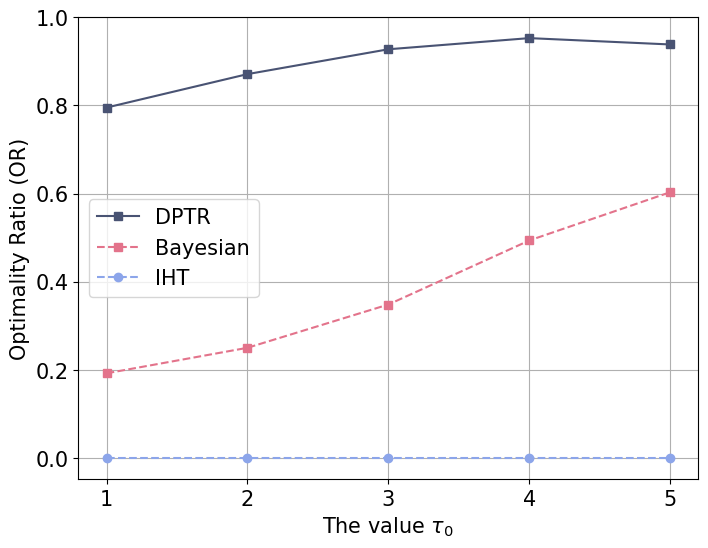

In [14]:
plt.figure(figsize=(8,6))
cost1 = np.mean(cost,axis=2)
plt.xlabel(r'The value $\tau_0$',fontsize=15)
plt.ylabel('Optimality Ratio (OR)',fontsize=15)
y3 = cost1[:,1]
plt.plot(anchor_set, y3,  color = '#495373',marker = "s",label = "DPTR")

y3 = cost1[:,2]
plt.plot(anchor_set, y3, color = '#E3738B',marker = "s",label = "Bayesian",linestyle = '--')

y3 = cost1[:,0]
plt.plot(anchor_set, y3, color = '#8CA5EA',linestyle = '--', marker='o',label = "IHT")



plt.xticks([1,2,3,4,5],fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid()
plt.savefig('scenario3_figures/performance_compare_with_tau0_correlation_K_{}_DiM.png'.format(K),dpi=300,bbox_inches = 'tight')
plt.show()

#### 2,change with variacne of error term

In [15]:
# parameters setting
K = 5
T = 1000
#Z = norm.ppf(0.975)
N = 10
Z = t_dist.ppf(0.975,N)
anchor_mean  = 1
std_noise_set = [1,2,3,4,5]


cost = np.zeros((len(std_noise_set),3,T))
anchor_mean = 1
for idx,std_niose in enumerate(std_noise_set):
    for t in tqdm(range(T)):
        true_tao = np.random.normal(anchor_mean, 3, K )
        constant = np.random.normal(anchor_mean, 3)
        optimal_cost = np.sum(true_tao[np.argwhere(true_tao>0)])

        # generate data
        feature = np.ones((N+K, K+1)) 
        feature[:, 1:] = np.random.binomial(1, 0.5, (N+K,K))

        # generate label
        label = constant + np.dot(feature[:,1:], true_tao) + np.random.normal(0, std_niose, N+K)

        #estimated tao
        model = sm.OLS(label, feature).fit()
        estimated_tao = model.params
        p_value = model.pvalues[1:]
        cov_matrix = model.cov_params()

        estimated_variance = np.zeros(K)
        for i in range(K):
            estimated_variance[i] = cov_matrix[i+1,i+1]
        #estimated_variance = np.sum((label - feature@estimated_tao)**2)/(N)*np.linalg.inv(feature.T@feature)

        hat_ATE = estimated_tao[1:]

        
        #estimated cost
        decision1 = np.argwhere(hat_ATE>(Z*np.sqrt(estimated_variance)))
        if optimal_cost == 0:
            if len(decision1) == 0:
                cost[idx,0,t] = 1
            else:
                cost[idx,0,t] = 0
        else:
            cost[idx,0,t] = np.sum(true_tao[decision1])/optimal_cost
        tau_0 = np.mean(hat_ATE)

        
        bayesian_tao = np.zeros(K)
        bayesian_beta = np.zeros(K)
        denumerator = np.var(hat_ATE) - np.mean(estimated_variance)
        decision3 = []
  
        for k in range(K):
            if denumerator <= 0:
                theta = 1
                posteri_mean = hat_ATE[k]*theta + (1 - theta)*tau_0
                posteri_var = 1/(1/estimated_variance[k])
                dist = norm(loc=posteri_mean, scale=np.sqrt(posteri_var))
                prob = dist.sf(0)  # survival function: P(X > x)
                if prob > 1 - 0.025:
                    decision3.append(k)
            else:
                bayesian_beta[k] = max(N*estimated_variance[k]/denumerator,0)
                theta = N/(N+bayesian_beta[k])
                posteri_mean = hat_ATE[k]*theta + (1 - theta)*tau_0
                posteri_var = 1/(1/denumerator+ 1/estimated_variance[k])
                dist = norm(loc=posteri_mean, scale=np.sqrt(posteri_var))

                prob = dist.sf(0)  # survival function: P(X > x)
                if prob > 1 - 0.025:
                    decision3.append(k)
        if optimal_cost == 0:
            if len(decision3) == 0:
                cost[idx,2,t] = 1
            else:
                cost[idx,2,t] = 0
        else:
            cost[idx,2,t] = np.sum(true_tao[decision3])/optimal_cost

        
        
        if tau_0 == 0:
            cost[idx,1,t] = cost[idx,0,t]
            continue
        beta = N*np.mean(estimated_variance)/(np.var(hat_ATE) - np.mean(estimated_variance)) +  Z*N*np.sqrt(np.mean(estimated_variance))/tau_0
        beta = max(0,beta)
        theta = N/(N+beta)
        shrunken_ATE = theta*hat_ATE + (1-theta)*tau_0
        decision2 = np.argwhere(shrunken_ATE>(theta*Z*np.sqrt(estimated_variance))/np.sqrt(N))

        if optimal_cost == 0:
            if len(decision2) == 0:
                cost[idx,1,t] = 1
            else:
                cost[idx,1,t] = 0
        else:
            cost[idx,1,t] = np.sum(true_tao[decision2])/optimal_cost

100%|██████████| 1000/1000 [00:01<00:00, 951.13it/s]


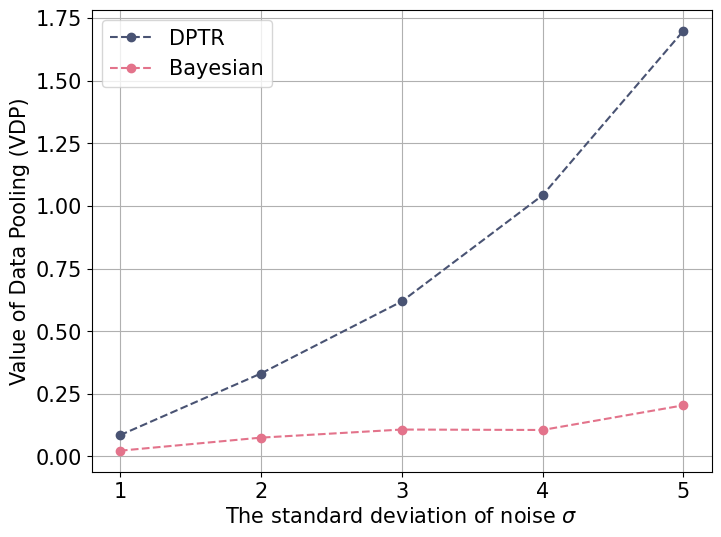

In [ ]:
y1 = np.mean(cost[:,0,:],axis=1)
y2 = np.mean(cost[:,1,:],axis=1)
y3 = np.mean(cost[:,2,:],axis=1)
plt.figure(figsize=(8,6))
plt.xlabel(r"The standard deviation of noise $\sigma$",fontsize=15)
plt.ylabel('Value of Data Pooling (VDP)',fontsize=15)

plt.plot(std_noise_set, [y2[i]/y1[i] - 1 for i in range(5)], color = '#495373',linestyle = '--', marker='o',label = "DPTR")
plt.plot(std_noise_set, [y3[i]/y1[i] - 1 for i in range(5)], color = '#E3738B',linestyle = '--', marker='o',label = "Bayesian")


plt.xticks(std_noise_set,fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid()
plt.savefig('scenario3_figures/performance_compare_with_sigma1_correlation_K_{}.png'.format(K),dpi=300,bbox_inches = 'tight')
plt.show()

#### 3，test the varaicne of $\hat{\tau}_0$

In [2]:
# parameters setting
T = 1000
N = 10
Z = t_dist.ppf(0.975,N)
std_niose = 3

anchor_mean = 1
K_list = [20,40,60,80,100]
tau_zero_list = []
for idx,K in enumerate(K_list):
    tao_zero_array_with_K = np.zeros(T)
    for t in tqdm(range(T)):
        true_tao = np.random.normal(anchor_mean, 3, K )
        constant = np.random.normal(anchor_mean, 3)
        optimal_cost = np.sum(true_tao[np.argwhere(true_tao>0)])

        # generate data
        feature = np.ones((N+K, K+1)) 
        feature[:, 1:] = np.random.binomial(1, 0.5, (N+K,K))

        # generate label
        label = constant + np.dot(feature[:,1:], true_tao) + np.random.normal(0, std_niose, N+K)

        #estimated tao
        model = sm.OLS(label, feature).fit()
        estimated_tao = model.params
        p_value = model.pvalues[1:]
        cov_matrix = model.cov_params()

        estimated_variance = np.zeros(K)
        for i in range(K):
            estimated_variance[i] = cov_matrix[i+1,i+1]
        #estimated_variance = np.sum((label - feature@estimated_tao)**2)/(N)*np.linalg.inv(feature.T@feature)

        hat_ATE = estimated_tao[1:]
        tau_0 = np.mean(hat_ATE)

        tao_zero_array_with_K[t] = tau_0
    tau_zero_list.append(tao_zero_array_with_K)

        
        

        
        
      

100%|██████████| 1000/1000 [00:02<00:00, 379.43it/s]


/var/folders/65/_vr9jby55k19n2k9gz801l3c0000gn/T/ipykernel_3916/2230184901.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


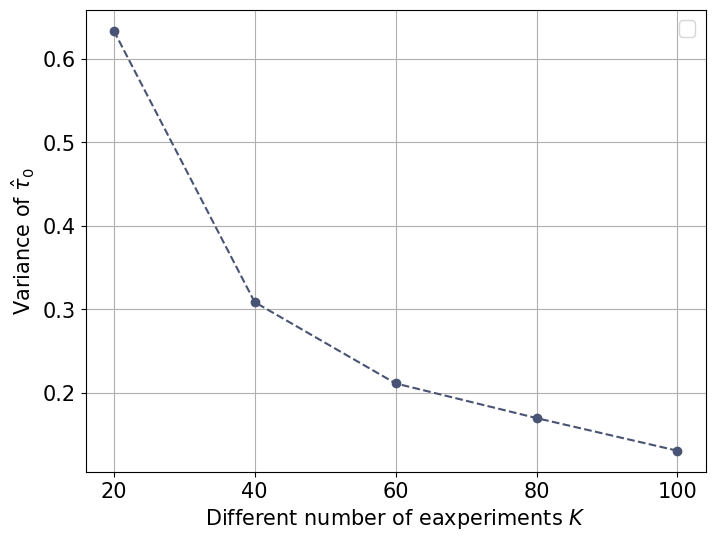

In [5]:
y1 = [np.var(tau_zero_list[i]) for i in range(len(tau_zero_list))]
plt.figure(figsize=(8,6))
plt.xlabel(r"Different number of eaxperiments $K$",fontsize=15)
plt.ylabel(r'Variance of $\hat{\tau}_0$',fontsize=15)

plt.plot(K_list, y1, color = '#495373',linestyle = '--', marker='o')


plt.xticks(K_list,fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid()
plt.savefig('scenario3_figures/variance_of_hat_tau_0_with_K.png',dpi=300,bbox_inches = 'tight')
plt.show()